In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from tqdm import tqdm

In [3]:
import mctpy as mct

In [4]:
Sq = mct.structurefactors.hssPY(0.548)
qgrid = np.linspace(0.2,39.8,100)

In [5]:
model = mct.granular.granular_model(Sq,qgrid,restitution_coeff=0.5)

In [6]:
nep = mct.nonergodicity_parameter (model = model, maxiter=1500)
nep.solve()

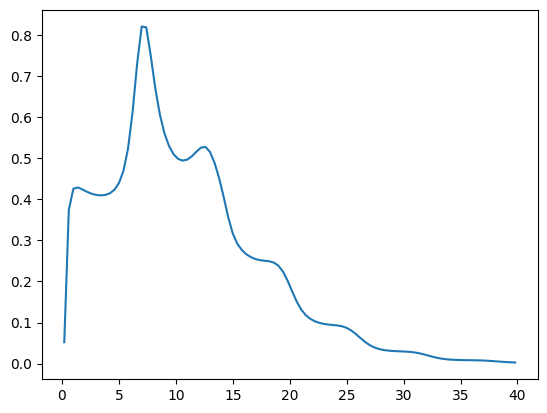

In [7]:
plt.plot(nep.model.q, nep.f)
plt.show()

In [8]:
def calc_ev(phi,eps):
    Sq = mct.structurefactors.hssPY(phi)
    model = mct.granular.granular_model (Sq, qgrid, restitution_coeff=eps)
    nep = mct.nonergodicity_parameter (model = model)
    nep.solve()
    ev = mct.eigenvalue(nep)
    ev.solve()
    return ev
epsrange = np.linspace(0,1,11)
phic = []
evals = []
for eps in epsrange:
    print("=== eps = {} ===".format(eps))
    phis, evs = mct.evscan(0.51,0.59,lambda phi:calc_ev(phi,eps),eps=1e-8)
    p=np.argmax([ev.eval for ev in evs])
    phic.append(phis[p])
    evals.append(evs[p])
phic = np.array(phic)

=== eps = 0.0 ===


=== eps = 0.1 ===


=== eps = 0.2 ===


=== eps = 0.30000000000000004 ===


=== eps = 0.4 ===


...

=== eps = 0.6000000000000001 ===


=== eps = 0.7000000000000001 ===


=== eps = 0.8 ===


=== eps = 0.9 ===


=== eps = 1.0 ===


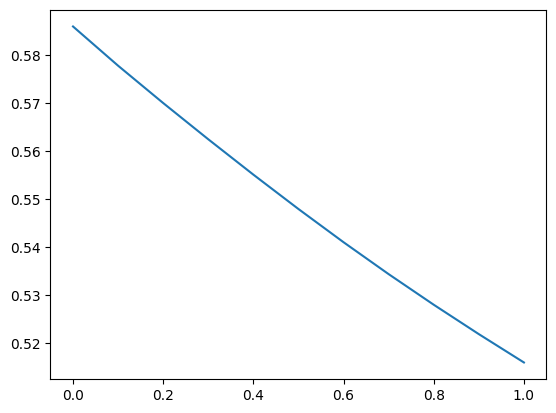

In [9]:
plt.plot(epsrange,phic)
plt.show()

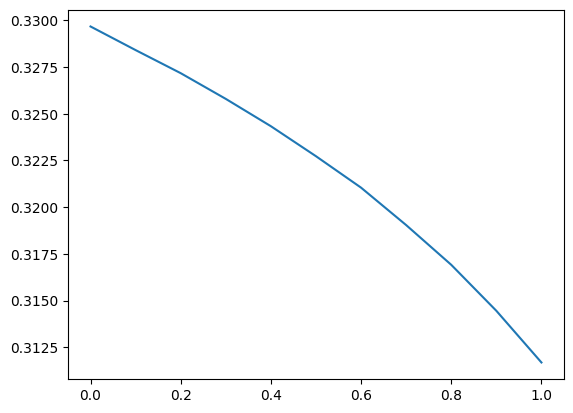

In [10]:
plt.plot(epsrange,[mct.exponents(ev.lam)[0] for ev in evals])
plt.show()

In [11]:
Sq = mct.structurefactors.hssPY(0.545)
model = mct.granular.granular_model(Sq,qgrid,restitution_coeff=0.5)
phi = mct.correlator (model = model, store=True)

adjusting to damped_newtonian dynamics


In [12]:
Sq0 = mct.structurefactors.hssPY(0.515)
model0 = mct.simple_liquid_model(Sq0,qgrid)
phi_bd = mct.correlator (model = model0, motion_type='brownian', store=True)
phi_nd = mct.correlator (model = model0, motion_type='newtonian', store=True)

In [13]:
correlators = mct.CorrelatorStack([phi,phi_bd,phi_nd])

In [14]:
pbar = tqdm(total=phi.blocks+1)
correlators.solve_all(callback=lambda d,bs2,bs,c: pbar.update(1))
pbar.close()

  0%|                                                    | 0/61 [00:00<?, ?it/s]

  2%|▋                                           | 1/61 [00:05<05:53,  5.90s/it]

  5%|██▏                                         | 3/61 [00:06<01:43,  1.78s/it]

  8%|███▌                                        | 5/61 [00:06<00:50,  1.12it/s]

 11%|█████                                       | 7/61 [00:06<00:29,  1.85it/s]

...

 89%|██████████████████████████████████████     | 54/61 [00:15<00:00, 12.47it/s]

 92%|███████████████████████████████████████▍   | 56/61 [00:15<00:00, 14.16it/s]

 95%|████████████████████████████████████████▉  | 58/61 [00:15<00:00, 15.56it/s]

 98%|██████████████████████████████████████████▎| 60/61 [00:15<00:00, 16.68it/s]

100%|███████████████████████████████████████████| 61/61 [00:15<00:00,  3.97it/s]

In [15]:
qvals = [4.2]
qis = np.array([np.nonzero(np.isclose(qgrid,qval)) for qval in qvals],dtype=int).reshape(-1)

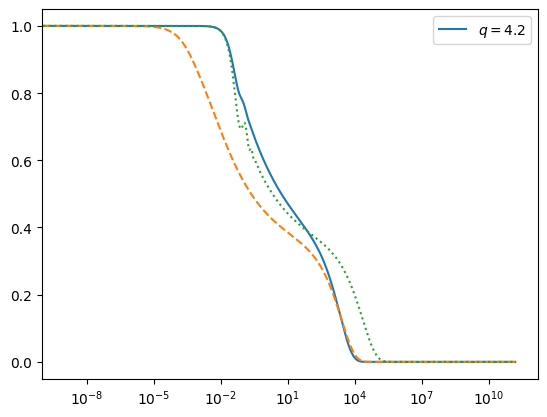

In [16]:
for qi in qis:
    plt.plot(phi.t, phi.phi[:,qi], label=r'$q = {:.1f}$'.format(qgrid[qi]))
    plt.plot(phi_bd.t,phi_bd.phi[:,qi],linestyle='dashed')
    plt.plot(phi_nd.t,phi_nd.phi[:,qi],linestyle='dotted')
plt.xscale('log')
plt.legend()
plt.show()

In [17]:
model_shear = mct.granular.gitt_model(Sq,qgrid,restitution_coeff=0.5,gammadot=1e-3)
phi_shear = mct.correlator (model = model_shear, store=True)

adjusting to damped_newtonian dynamics


In [18]:
pbar = tqdm(total=phi.blocks+1)
phi_shear.solve_all(callback=lambda d,bs2,bs,c: pbar.update(1))
pbar.close()

  0%|                                                    | 0/61 [00:00<?, ?it/s]

  2%|▋                                           | 1/61 [00:01<01:56,  1.94s/it]

  8%|███▌                                        | 5/61 [00:02<00:17,  3.17it/s]

 15%|██████▍                                     | 9/61 [00:02<00:08,  6.14it/s]

 20%|████████▍                                  | 12/61 [00:02<00:06,  8.15it/s]

...

 72%|███████████████████████████████            | 44/61 [00:05<00:01, 15.72it/s]

 79%|█████████████████████████████████▊         | 48/61 [00:05<00:00, 20.22it/s]

 87%|█████████████████████████████████████▎     | 53/61 [00:05<00:00, 26.51it/s]

 95%|████████████████████████████████████████▉  | 58/61 [00:05<00:00, 31.52it/s]

100%|███████████████████████████████████████████| 61/61 [00:05<00:00, 10.68it/s]

In [19]:
G = phi_shear.shear_modulus()

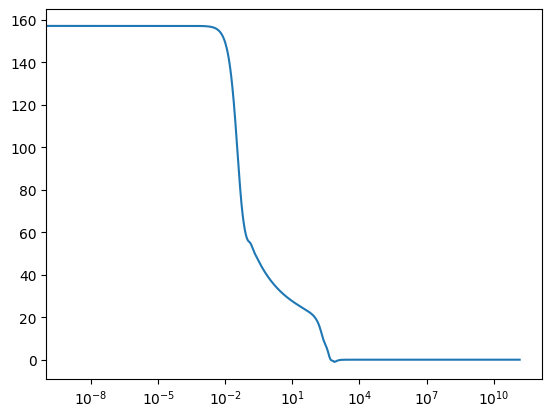

In [20]:
plt.plot(phi.t,G)
plt.xscale('log')
plt.show()